In [ ]:
!pip install numpy==1.26.4 deepctr-torch scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import os
import re

# =========================
# Configuration and Path Settings
# =========================
output_dir = '/content'

# 2023 Dataset file paths
PATH_SCORES_2023 = os.path.join(output_dir, 'users_scores_cleaned.csv')
PATH_USERS_2023 = os.path.join(output_dir, 'users_details_cleaned.csv')
PATH_ANIME = os.path.join(output_dir, 'anime_cleaned_no_airing.csv')

# Output file paths
OUTPUT_ANIME_FEAT = os.path.join(output_dir, 'anime_features_encoded.csv')
OUTPUT_FM_DATASET = os.path.join(output_dir, 'fm_dataset_2023.csv')

# Feature engineering configuration
TOP_K_GENRES = 30       # Keep the top 30 genres, but since the volume is limited, actually all are kept
TOP_K_STUDIOS = 20      # Keep top 20 studios


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR = '/content/drive/MyDrive/Colab_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# =========================
# Helper Functions
# =========================
def clean_placeholders(val):
    """Clean placeholders '-', 'Unknown', '?' to NaN"""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s in ["-", "Unknown", "unknown", "?", "None", "nan", "NaN", ""]:
        return np.nan
    return s

def extract_minutes(duration_str):
    """Extract duration in minutes from string, e.g., '24 min per ep' -> 24"""
    if pd.isna(duration_str):
        return 0
    m = re.search(r"(\d+)", str(duration_str))
    return int(m.group(1)) if m else 0

# ==============================================================================
# [Dataset A] 2023 User Stratification Processing
# ==============================================================================
print("=" * 50)
print("1. Start processing 2023 User Stratification (Dynamic labeling based on real rating count + One-Hot encoding)")
print("=" * 50)

# 1. Directly read the real large rating table
df_scores_for_tier = pd.read_csv(PATH_SCORES_2023)

# Unify possible column name spelling errors to prevent future explosions
if 'animie_id' in df_scores_for_tier.columns:
    df_scores_for_tier.rename(columns={'animie_id': 'anime_id'}, inplace=True)

# 2. [Core Fix] Calculate the real rating count for each user
user_activity = df_scores_for_tier.groupby('user_id').size().reset_index(name='rating_count')

# 3. Dynamically calculate real quantiles (still 10% and 50% ratio)
q90 = user_activity['rating_count'].quantile(0.90)
q50 = user_activity['rating_count'].quantile(0.50)

print(f"Activity benchmark used: Real Rating Count")
print(f"Dynamic thresholds: Veteran (Top 10%) > {q90:.0f} ratings, Casual (Bottom 50%) <= {q50:.0f} ratings")

# 4. Define text labels
def get_tier_label(count):
    if count > q90: return 'High_Activity'
    elif count <= q50: return 'Low_Activity'
    else: return 'Medium_Activity'

# 5. Apply text-based Tier on the spot
user_activity['Activity_Level'] = user_activity['rating_count'].apply(get_tier_label)

# 6. Core: Convert text labels to One-Hot encoding, directly into three independent columns
tier_dummies = pd.get_dummies(user_activity['Activity_Level'], prefix='Tier').astype(int)

# 7. Concatenate into the final pure user feature table fed only to FM (keep only user_id and three one-hot columns)
df_users_fm = pd.concat([user_activity[['user_id']], tier_dummies], axis=1)

print("User-side one-hot encoding completed, preview:")
print(df_users_fm.head(3))


1. Start processing 2023 User Stratification (Dynamic labeling based on real rating count + One-Hot encoding)
Activity benchmark used: Real Rating Count
Dynamic thresholds: Veteran (Top 10%) > 177 ratings, Casual (Bottom 50%) <= 31 ratings
User-side one-hot encoding completed, preview:
   user_id  Tier_High_Activity  Tier_Low_Activity  Tier_Medium_Activity
0        1                   1                  0                     0
1        9                   0                  0                     1
2       20                   0                  0                     1


In [ ]:
# ==============================================================================
# [Dataset A] Anime-side Feature Engineering (One-Hot)
# ==============================================================================
print("\n" + "=" * 50)
print("2. Start processing 2023 Anime Features")
print("=" * 50)

df_anime = pd.read_csv(PATH_ANIME)

# Basic cleaning
for col in ["genres", "type", "rating", "source", "studios", "duration"]:
    if col in df_anime.columns:
        df_anime[col] = df_anime[col].apply(clean_placeholders)

# Extract numerical features
df_anime["episodes"] = pd.to_numeric(df_anime["episodes"], errors="coerce").fillna(0)
df_anime["duration_min"] = df_anime["duration"].apply(extract_minutes)
df_anime["log_members"] = np.log1p(pd.to_numeric(df_anime["members"], errors="coerce").fillna(0))

# Extract baseline feature table (kept id for subsequent merge)
anime_features = df_anime[["id", "title"]].copy()
anime_features.rename(columns={'id': 'anime_id'}, inplace=True) # Unify naming to anime_id for easy merging
anime_features["episodes"] = df_anime["episodes"]
anime_features["duration_min"] = df_anime["duration_min"]
anime_features["log_members"] = df_anime["log_members"]

# (A) Genres One-Hot encoding
G = df_anime["genres"].str.get_dummies(sep=", ")
G.columns = [c.strip().lower() for c in G.columns]
freq_g = G.sum().sort_values(ascending=False)
keep_g = freq_g.head(TOP_K_GENRES).index.tolist()
anime_features = pd.concat([anime_features, G[keep_g].add_prefix("Genre_")], axis=1)

# (B) Studios One-Hot encoding
S = df_anime["studios"].fillna("").str.get_dummies(sep=", ")
S.columns = [c.strip().lower() for c in S.columns]
freq_s = S.sum().sort_values(ascending=False)
keep_s = freq_s.head(TOP_K_STUDIOS).index.tolist()
anime_features = pd.concat([anime_features, S[keep_s].add_prefix("Studio_")], axis=1)

# (C) Type, Rating, Source One-Hot encoding
T = pd.get_dummies(df_anime["type"], prefix="Type", dummy_na=False).astype(int)
R = pd.get_dummies(df_anime["rating"], prefix="Rating", dummy_na=False).astype(int)
Src = pd.get_dummies(df_anime["source"], prefix="Source", dummy_na=False).astype(int)

anime_features = pd.concat([anime_features, T, R, Src], axis=1)

# Save a pure anime feature table as backup
anime_features.to_csv(OUTPUT_ANIME_FEAT, index=False)
print(f"Anime-side feature extraction completed, shape: {anime_features.shape}")



2. Start processing 2023 Anime Features
Anime-side feature extraction completed, shape: (15533, 74)


In [ ]:
# ==============================================================================
# The Grand Merge -> Construct wide table directly acceptable by FM
# ==============================================================================
print("\n" + "=" * 50)
print("3. The Grand Unification: Merge ratings, user stratification, and anime tags")
print("=" * 50)

# 1. Load rating table (contains user_id, anime_id, rating)
df_scores = pd.read_csv(PATH_SCORES_2023)

# Correct possible column name spelling errors (animie_id -> anime_id)
if 'animie_id' in df_scores.columns:
    df_scores.rename(columns={'animie_id': 'anime_id'}, inplace=True)

print(f"Original rating record count: {len(df_scores)}")

# 2. Merge user-side features (One-hot Tiers) into rating table
df_merged = pd.merge(df_scores, df_users_fm, on='user_id', how='inner')

# 3. Merge item-side features (Genres, Studios, etc.) into rating table
anime_features['official_score'] = df_anime['score'].values
df_merged = pd.merge(df_merged, anime_features, on='anime_id', how='inner')

print(f"Total record count after merging: {len(df_merged)}")

# Save as the final FM training wide table
df_merged.to_csv(OUTPUT_FM_DATASET, index=False)

print(f"\n✅ Perfect! FM exclusive training set generated and saved to: {OUTPUT_FM_DATASET}")
print("Preview of merged features (includes ratings, activity tiers, and high-dimensional sparse tags):")
print(df_merged.columns.tolist()[:120], "...") # Print all column names, because the csv is too large to open, can only check this part like this


3. The Grand Unification: Merge ratings, user stratification, and anime tags
Original rating record count: 13706708
Total record count after merging: 13646339

✅ Perfect! FM exclusive training set generated and saved to: /content/fm_dataset_2023.csv
Preview of merged features (includes ratings, activity tiers, and high-dimensional sparse tags):
['user_id', 'anime_id', 'rating', 'Tier_High_Activity', 'Tier_Low_Activity', 'Tier_Medium_Activity', 'title', 'episodes', 'duration_min', 'log_members', 'Genre_comedy', 'Genre_action', 'Genre_fantasy', 'Genre_adventure', 'Genre_sci-fi', 'Genre_drama', 'Genre_romance', 'Genre_hentai', 'Genre_supernatural', 'Genre_slice of life', 'Genre_ecchi', 'Genre_mystery', 'Genre_sports', 'Genre_avant garde', 'Genre_horror', 'Genre_award winning', 'Genre_suspense', 'Genre_boys love', 'Genre_gourmet', 'Genre_girls love', 'Genre_erotica', 'Studio_toei animation', 'Studio_sunrise', 'Studio_j.c.staff', 'Studio_madhouse', 'Studio_production i.g', 'Studio_studio d

#check the code

In [ ]:
peek_df = pd.read_csv('/content/fm_dataset_2023.csv', nrows=10)

# Print to see if the data is perfectly aligned
print("Preview of first 5 rows of data:")
display(peek_df.head())

# Check memory usage and data types
print("\nData table structure information:")
peek_df.info()

Preview of first 5 rows of data:


,user_id,anime_id,rating,Tier_High_Activity,Tier_Low_Activity,Tier_Medium_Activity,title,episodes,duration_min,log_members,...,Source_music,Source_novel,Source_original,Source_other,Source_picture book,Source_radio,Source_visual novel,Source_web manga,Source_web novel,official_score
0,1,48,7,1,0,0,hack sign,26,24,12.093240,...,0,0,1,0,0,0,0,0,0,6.95
1,1,320,5,1,0,0,a kite,2,26,11.109788,...,0,0,1,0,0,0,0,0,0,6.54
2,1,49,8,1,0,0,aa megami-sama,5,30,10.871004,...,0,0,0,0,0,0,0,0,0,7.29
3,1,304,8,1,0,0,aa megami-sama movie,1,1,10.648397,...,0,0,1,0,0,0,0,0,0,7.54
4,1,306,8,1,0,0,abenobashi mahou shoutengai,13,24,11.373433,...,0,0,1,0,0,0,0,0,0,7.23



Data table structure information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                10 non-null     int64  
 1   anime_id                               10 non-null     int64  
 2   rating                                 10 non-null     int64  
 3   Tier_High_Activity                     10 non-null     int64  
 4   Tier_Low_Activity                      10 non-null     int64  
 5   Tier_Medium_Activity                   10 non-null     int64  
 6   title                                  10 non-null     object 
 7   episodes                               10 non-null     int64  
 8   duration_min                           10 non-null     int64  
 9   log_members                            10 non-null     float64
 10  Genre_comedy                           10 

In [ ]:
print("=" * 60)
print("[Diagnosis 1] Real distribution of user rating counts")
print("=" * 60)
user_rating_counts = df_merged.groupby('user_id')['rating'].count()
print(f"Total unique users: {user_rating_counts.nunique()}")
print(f"Rating count Median: {user_rating_counts.median():.0f}")
print(f"Rating count Mean:   {user_rating_counts.mean():.1f}")
print(f"Rating count Quantiles:")
print(user_rating_counts.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print(f"\nProportion of users with rating count < 5:  {(user_rating_counts < 5).mean():.3f}")
print(f"Proportion of users with rating count < 10: {(user_rating_counts < 10).mean():.3f}")
print(f"Proportion of users with rating count >= 20: {(user_rating_counts >= 20).mean():.3f}")

print("\n" + "=" * 60)
print("[Diagnosis 2] Are there real differences in ratings per user within the three Tiers?")
print("=" * 60)
for tier, col in [('Veteran', 'Tier_High_Activity'),
                  ('Intermediate', 'Tier_Medium_Activity'),
                  ('Casual', 'Tier_Low_Activity')]:
    counts = df_merged[df_merged[col] == 1].groupby('user_id')['rating'].count()
    print(f"\n{tier}:")
    print(f"  User count: {len(counts)}")
    print(f"  Ratings per user Median: {counts.median():.0f} | Mean: {counts.mean():.1f} | Max: {counts.max()}")
    print(f"  Proportion of users with rating count >= 10: {(counts >= 10).mean():.3f}")

print("\n" + "=" * 60)
print("[Diagnosis 3] Stratification threshold is based on episodes_watched, but rating count is another matter")
print("=" * 60)
eps_col = 'episodes_watched' if 'episodes_watched' in df_merged.columns else None
if eps_col:
    for tier, col in [('Veteran', 'Tier_High_Activity'),
                      ('Intermediate', 'Tier_Medium_Activity'),
                      ('Casual', 'Tier_Low_Activity')]:
        # Actually episodes_watched is user-level, deduplicate first
        sub = df_merged[df_merged[col] == 1].drop_duplicates('user_id')[eps_col]
        print(f"{tier} episodes_watched Median: {sub.median():.0f} | Mean: {sub.mean():.1f}")

print("\n" + "=" * 60)
print("[Diagnosis 4] Is there a score column (official score) in df_merged?")
print("=" * 60)
score_cols = [c for c in df_merged.columns if 'score' in c.lower()]
print(f"Columns containing 'score': {score_cols}")
print(f"Total columns: {len(df_merged.columns)}")
print(f"Total rows: {len(df_merged)}")

# This part was randomly written by AI, mainly used to check and detect sample stratification issues at the beginning

[Diagnosis 1] Real distribution of user rating counts
Total unique users: 434
Rating count Median: 31
Rating count Mean:   61.7
Rating count Quantiles:
0.10      2.0
0.25      8.0
0.50     31.0
0.75     90.0
0.90    176.0
0.95    228.0
0.99    289.0
Name: rating, dtype: float64

Proportion of users with rating count < 5:  0.169
Proportion of users with rating count < 10: 0.278
Proportion of users with rating count >= 20: 0.594

[Diagnosis 2] Are there real differences in ratings per user within the three Tiers?

Veteran:
  User count: 21989
  Ratings per user Median: 228 | Mean: 234.2 | Max: 1338
  Proportion of users with rating count >= 10: 1.000

Intermediate:
  User count: 87914
  Ratings per user Median: 74 | Mean: 83.2 | Max: 177
  Proportion of users with rating count >= 10: 1.000

Casual:
  User count: 111257
  Ratings per user Median: 8 | Mean: 10.6 | Max: 31
  Proportion of users with rating count >= 10: 0.448

[Diagnosis 3] Stratification threshold is based on episodes_watch

In [ ]:
"""
============================================================
采样分布验证 v2 (修复版)
============================================================
修复内容：
  1. 连续特征：只比较 df_mini 归一化之前的原始值，
     或者反过来对 df_merged 做同样的归一化再比较
  2. 单 tier 验证时跳过 tier 分布检验（本来就是 100%/0%/0%）
  3. Rating 卡方加上 effect size 判断

用法：贴到 Cell 9 的采样代码之后、归一化之前运行
      如果已经归一化了，用方案B（见底部）
============================================================
"""

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


def verify_sampling_v2(df_full, df_sample, label="采样子集",
                       skip_tier_check=False,
                       continuous_cols_to_check=None):
    """
    参数:
        df_full: 全量数据（未归一化）
        df_sample: 采样数据（必须和 df_full 在同一尺度下，即未归一化）
        skip_tier_check: 单tier验证时设为True，跳过无意义的tier分布检验
        continuous_cols_to_check: 要检验的连续列名列表，None则自动检测
    """

    print("=" * 70)
    print(f"采样分布验证报告 v2")
    print(f"全量: {len(df_full):,} 行 → {label}: {len(df_sample):,} 行 ({len(df_sample)/len(df_full)*100:.1f}%)")
    print("=" * 70)

    results = []

    # ========================================
    # 1. Tier 比例 (仅在全量验证时有意义)
    # ========================================
    tier_cols = ['Tier_High_Activity', 'Tier_Medium_Activity', 'Tier_Low_Activity']
    tier_names = ['Veteran', 'Intermediate', 'Casual']

    # 兼容列名
    if tier_cols[0] not in df_full.columns:
        for alt in [c.replace('_', '.') for c in tier_cols]:
            if alt in df_full.columns:
                tier_cols = [c.replace('_', '.') for c in tier_cols]
                break

    if not skip_tier_check and all(c in df_full.columns for c in tier_cols):
        print("\n── 【1】Tier 比例 ──")
        full_counts = []
        sample_counts = []
        for col, name in zip(tier_cols, tier_names):
            fc = (df_full[col] == 1).sum()
            sc = (df_sample[col] == 1).sum()
            full_counts.append(fc)
            sample_counts.append(sc)
            fp = fc / len(df_full) * 100
            sp = sc / len(df_sample) * 100
            print(f"  {name:15s} | 全量: {fp:6.2f}%  |  采样: {sp:6.2f}%  |  偏差: {abs(fp-sp):.2f}%")

        exp_prop = np.array(full_counts) / sum(full_counts)
        exp = exp_prop * sum(sample_counts)
        valid = exp > 0
        if valid.sum() >= 2:
            chi2, p = stats.chisquare(np.array(sample_counts)[valid], f_exp=exp[valid])
            s = "✅" if p > 0.05 else "⚠️"
            print(f"  卡方: χ²={chi2:.4f}, p={p:.6f} → {s}")
            results.append(('Tier比例', chi2, p, s))

    # ========================================
    # 2. Rating 分布 (卡方 + effect size)
    # ========================================
    print("\n── 【2】Rating 分布 ──")
    if 'rating' in df_full.columns:
        full_dist = df_full['rating'].value_counts().sort_index()
        samp_dist = df_sample['rating'].value_counts().sort_index()
        all_r = sorted(set(full_dist.index) | set(samp_dist.index))
        fc = np.array([full_dist.get(r, 0) for r in all_r], dtype=float)
        sc = np.array([samp_dist.get(r, 0) for r in all_r], dtype=float)

        max_dev = 0
        print(f"  {'Rating':>6s} | {'全量%':>7s} | {'采样%':>7s} | {'偏差':>5s}")
        for r, f, s in zip(all_r, fc, sc):
            fp = f / fc.sum() * 100
            sp = s / sc.sum() * 100
            dev = abs(fp - sp)
            max_dev = max(max_dev, dev)
            print(f"  {r:6.0f}| {fp:6.2f}% | {sp:6.2f}% | {dev:.2f}%")

        exp_prop = fc / fc.sum()
        exp = exp_prop * sc.sum()
        valid = exp > 0
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])

        # 关键：用 effect size 判断，不只看 p-value
        # Cramér's V = sqrt(χ² / (n * (k-1)))
        k = valid.sum()
        n = sc.sum()
        cramers_v = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        if max_dev < 1.0 and cramers_v < 0.05:
            verdict = "✅ 实际差异可忽略"
            tag = "✅"
        elif p > 0.05:
            verdict = "✅ 无显著差异"
            tag = "✅"
        else:
            verdict = "⚠️ 有差异，需看 effect size"
            tag = "⚠️"

        print(f"\n  卡方: χ²={chi2:.2f}, p={p:.6f}")
        print(f"  最大单类偏差: {max_dev:.2f}%")
        print(f"  Cramér's V = {cramers_v:.4f} (< 0.05 = 可忽略, < 0.1 = 小, < 0.3 = 中)")
        print(f"  → {verdict}")
        results.append(('Rating分布', cramers_v, p, tag))

    # ========================================
    # 3. 连续特征 (KS 检验)
    # 注意：必须在同一尺度下比较！
    # ========================================
    print("\n── 【3】连续特征 (KS检验) ──")

    if continuous_cols_to_check is None:
        candidates = ['log_members', 'official_score', 'episodes',
                      'duration_min', 'delta_r', 'episodes_watched']
        continuous_cols_to_check = []
        for col in candidates:
            for v in [col, col.replace('_', '.'), col.replace('_', '-')]:
                if v in df_full.columns and v in df_sample.columns:
                    continuous_cols_to_check.append(v)
                    break

    for col in continuous_cols_to_check:
        fv = df_full[col].dropna()
        sv = df_sample[col].dropna()

        # ★ 关键安全检查：两边是否在同一尺度？
        f_range = (fv.min(), fv.max())
        s_range = (sv.min(), sv.max())

        if f_range[1] > 0 and s_range[1] > 0:
            scale_ratio = f_range[1] / s_range[1]
        else:
            scale_ratio = 1.0

        if scale_ratio > 5 or scale_ratio < 0.2:
            print(f"\n  {col}: ⛔ 尺度不匹配！")
            print(f"    全量 range: [{f_range[0]:.2f}, {f_range[1]:.2f}]")
            print(f"    采样 range: [{s_range[0]:.4f}, {s_range[1]:.4f}]")
            print(f"    → 该列在采样后被归一化了，跳过（不影响结论）")
            results.append((col, None, None, '⏭️ 已归一化,跳过'))
            continue

        ks_d, p = stats.ks_2samp(fv, sv)

        # effect size 判断
        if ks_d < 0.05:
            tag = "✅"
            note = "D < 0.05, 实际差异可忽略"
        elif p > 0.05:
            tag = "✅"
            note = "无显著差异"
        else:
            tag = "⚠️"
            note = f"D={ks_d:.4f}, 需看实际偏移量"

        print(f"\n  {col}:")
        print(f"    全量  mean={fv.mean():.4f}, median={fv.median():.4f}, std={fv.std():.4f}")
        print(f"    采样  mean={sv.mean():.4f}, median={sv.median():.4f}, std={sv.std():.4f}")
        print(f"    KS: D={ks_d:.4f}, p={p:.6f} → {tag} ({note})")
        results.append((col, ks_d, p, tag))

    # ========================================
    # 4. 各 Tier 内部 Rating (分层卡方)
    # ========================================
    print("\n── 【4】各 Tier 内部 Rating ──")
    for col, name in zip(tier_cols, tier_names):
        if col not in df_full.columns:
            continue
        ft = df_full[df_full[col] == 1]['rating']
        st = df_sample[df_sample[col] == 1]['rating']
        if len(ft) == 0 or len(st) == 0:
            continue

        all_r = sorted(set(ft.unique()) | set(st.unique()))
        fc = np.array([(ft == r).sum() for r in all_r], dtype=float)
        sc = np.array([(st == r).sum() for r in all_r], dtype=float)

        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        if valid.sum() < 2:
            continue

        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        n = sc.sum()
        k = valid.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        max_dev = max(abs(f/fc.sum() - s/sc.sum()) * 100 for f, s in zip(fc, sc))

        if max_dev < 1.5 and cv < 0.05:
            tag = "✅"
        elif p > 0.05:
            tag = "✅"
        else:
            tag = "⚠️"

        print(f"  {name:15s} | Cramér's V={cv:.4f}, 最大偏差={max_dev:.2f}%, p={p:.6f} → {tag}")
        results.append((f'{name}内Rating', cv, p, tag))

    # ========================================
    # 5. 每用户评分数分布 (KS)
    # ========================================
    print("\n── 【5】每用户评分数量 ──")
    fu = df_full.groupby('user_id')['rating'].count()
    su = df_sample.groupby('user_id')['rating'].count()
    ks_d, p = stats.ks_2samp(fu, su)
    tag = "✅" if (p > 0.05 or ks_d < 0.05) else "⚠️"
    print(f"  全量  用户数:{len(fu):,}, 中位数:{fu.median():.0f}, 均值:{fu.mean():.1f}")
    print(f"  采样  用户数:{len(su):,}, 中位数:{su.median():.0f}, 均值:{su.mean():.1f}")
    print(f"  KS: D={ks_d:.4f}, p={p:.6f} → {tag}")
    results.append(('用户评分数', ks_d, p, tag))

    # ========================================
    # 汇总
    # ========================================
    print("\n" + "=" * 70)
    print("汇总")
    print("=" * 70)

    pass_count = 0
    skip_count = 0
    for name, stat, p, tag in results:
        stat_str = f"{stat:.4f}" if stat is not None else "N/A"
        p_str = f"{p:.6f}" if p is not None else "N/A"
        print(f"  {name:<22s} | stat={stat_str:>8s} | p={p_str:>10s} | {tag}")
        if "✅" in tag:
            pass_count += 1
        if "⏭️" in tag:
            skip_count += 1

    effective = len(results) - skip_count
    print(f"\n  通过: {pass_count}/{effective} (跳过{skip_count}个已归一化列)")

    if pass_count >= effective:
        print("\n  🎉 全部通过！采样分布与原始数据一致。")
        print("  论文可写:")
        print('  "User-level stratified sampling was performed at equal rates within')
        print('   each activity tier. Distribution fidelity was verified via chi-squared')
        print('   tests (discrete) and KS tests (continuous). Cramér\'s V < 0.05 and')
        print('   KS D < 0.05 across all dimensions confirm negligible distributional')
        print('   shift (all effect sizes below conventional small-effect thresholds)."')
    elif pass_count >= effective * 0.7:
        print("\n  ⚠️ 大部分通过，少数有微小偏移，但 effect size 很小则可接受")
    else:
        print("\n  ❌ 较多维度未通过，需检查采样逻辑")

    return results


#Officially Implementing FM
First, I performed stratified sampling on 5% of the data, and then applied the standard FM processing to each subset.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
# Because Colab doesn't have it, download it every time, it doesn't take long anyway

from deepctr_torch.inputs import SparseFeat, DenseFeat, VarLenSparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt# ==========================================
# 1. User-level Stratified Sampling
# Sample 5% of users, keep all rating records of these users
# ==========================================
print("Executing user-level stratified sampling...")

def sample_by_user(df_tier, frac, random_state=42):
    sampled_users = df_tier['user_id'].drop_duplicates().sample(frac=frac, random_state=random_state)
    return df_tier[df_tier['user_id'].isin(sampled_users)]

mask_high   = df_merged['Tier_High_Activity'] == 1
mask_medium = df_merged['Tier_Medium_Activity'] == 1
mask_low    = df_merged['Tier_Low_Activity'] == 1

df_high   = sample_by_user(df_merged[mask_high],   frac=0.5)
df_medium = sample_by_user(df_merged[mask_medium], frac=0.5)
df_low    = sample_by_user(df_merged[mask_low],    frac=0.5)

df_mini = pd.concat([df_high, df_medium, df_low], ignore_index=True)

# Verify user retention for each tier
for name, df_t in [('Veteran', df_high), ('Intermediate', df_medium), ('Casual', df_low)]:
    counts = df_t.groupby('user_id')['rating'].count()
    print(f"{name}: users={len(counts)}, median ratings per user={counts.median():.0f}")
print(f"Mini training set total rows: {len(df_mini)}")

# Clean column names
df_mini.columns   = [col.replace('.', '_').replace('-', '_').replace(' ', '_') for col in df_mini.columns]
df_merged.columns = [col.replace('.', '_').replace('-', '_').replace(' ', '_') for col in df_merged.columns]

# ==========================================
# 2. Calculate aesthetic deviation residual (delta_r)
# delta_r = User actual rating - MAL official Bayesian weighted score
# ==========================================
df_mini['delta_r'] = df_mini['rating'] - df_mini['official_score']

# 3. Feature Classification and Preprocessing
# ==========================================
dense_features  = ['episodes', 'duration_min', 'log_members']

# Define target variable for subsequent residual models
target = ['delta_r']

# --- Phase A: Continuous Feature Normalization ---
df_mini[dense_features] = df_mini[dense_features].fillna(0)
for feat in dense_features:
    df_mini[feat] = (df_mini[feat] - df_mini[feat].min()) / (df_mini[feat].max() - df_mini[feat].min() + 1e-8)

# --- Phase B: Restore Mutually Exclusive Features ---
# Convert mutually exclusive One-Hot encoded columns back to single categorical columns for SparseFeat encoding
def reverse_one_hot(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    return df[cols].idxmax(axis=1).fillna('Unknown')

df_mini['Type_Cat'] = reverse_one_hot(df_mini, 'Type_')
df_mini['Rating_Cat'] = reverse_one_hot(df_mini, 'Rating_')
df_mini['Source_Cat'] = reverse_one_hot(df_mini, 'Source_')
df_mini['Tier_Cat'] = reverse_one_hot(df_mini, 'Tier_')

id_features = ['user_id', 'anime_id', 'Type_Cat', 'Rating_Cat', 'Source_Cat', 'Tier_Cat']

for feat in id_features:
    lbe = LabelEncoder()
    df_mini[feat] = lbe.fit_transform(df_mini[feat])

# --- Phase C: Variable-Length Serialization for Multi-label Tags (VarLenSparseFeat) ---
# Map one-hot genres to a padded sequence of IDs
genre_cols = [c for c in df_mini.columns if c.startswith('Genre_')]
genre_matrix = df_mini[genre_cols].values.astype(np.int32)
genre_ids = np.arange(1, len(genre_cols) + 1, dtype=np.int32)
genre_tagged = genre_matrix * genre_ids[np.newaxis, :]
max_len_genre = int(genre_matrix.sum(axis=1).max())

# Pad length with zeros to maintain uniform matrix shape
genre_pad = np.zeros((len(df_mini), max_len_genre), dtype=np.int32)
for i in range(len(genre_tagged)):
    ids = genre_tagged[i][genre_tagged[i] > 0]
    genre_pad[i, :len(ids)] = ids
df_mini['genre_seq'] = list(genre_pad)
del genre_matrix, genre_tagged
import gc; gc.collect()

# Apply the same serialization process to Studios
studio_cols = [c for c in df_mini.columns if c.startswith('Studio_')]
studio_matrix = df_mini[studio_cols].values.astype(np.int32)
studio_ids = np.arange(1, len(studio_cols) + 1, dtype=np.int32)
studio_tagged = studio_matrix * studio_ids[np.newaxis, :]
max_len_studio = max(int(studio_matrix.sum(axis=1).max()), 1)
studio_pad = np.zeros((len(df_mini), max_len_studio), dtype=np.int32)
for i in range(len(studio_tagged)):
    ids = studio_tagged[i][studio_tagged[i] > 0]
    studio_pad[i, :len(ids)] = ids
df_mini['studio_seq'] = list(studio_pad)
del studio_matrix, studio_tagged, df_high, df_medium, df_low
gc.collect()

# ==========================================
# 4. Construct DeepCTR Feature Dictionary
# ==========================================
# 1. Base single-column discrete features
id_feature_columns = [SparseFeat(feat, vocabulary_size=df_mini[feat].nunique(), embedding_dim=8)
                      for feat in id_features]

# 2. Continuous features
continuous_feature_columns = [DenseFeat(feat, 1) for feat in dense_features]

# 3. Variable-length features with mean pooling logic
varlen_feature_columns = [
    VarLenSparseFeat(SparseFeat('genre_seq', vocabulary_size=len(genre_cols) + 1, embedding_dim=8), maxlen=max_len_genre, combiner='mean'),
    VarLenSparseFeat(SparseFeat('studio_seq', vocabulary_size=len(studio_cols) + 1, embedding_dim=8), maxlen=max_len_studio, combiner='mean')
]

fixlen_feature_columns = id_feature_columns + continuous_feature_columns + varlen_feature_columns
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns    = fixlen_feature_columns
feature_names          = get_feature_names(linear_feature_columns + dnn_feature_columns)

# ==========================================
# Data Splitting and DeepCTR Input Formatting
# ==========================================
train_global, test_global = train_test_split(df_mini, test_size=0.2, random_state=2026)
train, test = train_global, test_global

# Initialize dictionary with standard features
train_model_input = {name: train[name].values for name in feature_names if name not in ['genre_seq', 'studio_seq']}
test_model_input  = {name: test[name].values for name in feature_names if name not in ['genre_seq', 'studio_seq']}

# Explicitly cast variable-length features to 2D Numpy arrays to fulfill DeepCTR input requirements
train_model_input['genre_seq'] = np.vstack(train['genre_seq'].values)
test_model_input['genre_seq']  = np.vstack(test['genre_seq'].values)
train_model_input['studio_seq'] = np.vstack(train['studio_seq'].values)
test_model_input['studio_seq']  = np.vstack(test['studio_seq'].values)


Executing user-level stratified sampling...
Veteran: users=10994, median ratings per user=228
Intermediate: users=43957, median ratings per user=74
Casual: users=55628, median ratings per user=8
Mini training set total rows: 6818192


In [ ]:
print("=" * 70)
print("全局验证")
print("=" * 70)
verify_sampling_v2(df_merged, df_mini, "全局采样")
# === 数据泄露检查 ===
for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                             ('Tier_Medium_Activity', 'Intermediate'),
                             ('Tier_Low_Activity', 'Casual')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]
    leak = test_tier.index.isin(train_global.index)
    print(f"{tier_name}: tier-test {len(test_tier)}行, 其中{leak.sum()}行在全局train中 ({leak.mean()*100:.1f}%)")

# === 数据泄露检查 ===
for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                             ('Tier_Medium_Activity', 'Intermediate'),
                             ('Tier_Low_Activity', 'Casual')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]
    leak = test_tier.index.isin(train_global.index)
    print(f"{tier_name}: tier-test {len(test_tier)}行, 其中{leak.sum()}行在全局train中 ({leak.mean()*100:.1f}%)")


全局验证
采样分布验证报告 v2
全量: 13,646,339 行 → 全局采样: 6,818,192 行 (50.0%)

── 【1】Tier 比例 ──
  Veteran         | 全量:  37.73%  |  采样:  37.76%  |  偏差: 0.03%
  Intermediate    | 全量:  53.59%  |  采样:  53.56%  |  偏差: 0.03%
  Casual          | 全量:   8.68%  |  采样:   8.67%  |  偏差: 0.00%
  卡方: χ²=2.5990, p=0.272670 → ✅

── 【2】Rating 分布 ──
  Rating |     全量% |     采样% |    偏差
       1|   0.38% |   0.38% | 0.01%
       2|   0.47% |   0.48% | 0.01%
       3|   0.77% |   0.77% | 0.01%
       4|   1.95% |   1.95% | 0.01%
       5|   4.81% |   4.80% | 0.02%
       6|   9.77% |   9.74% | 0.03%
       7|  20.60% |  20.56% | 0.03%
       8|  24.73% |  24.71% | 0.02%
       9|  20.35% |  20.36% | 0.02%
      10|  16.18% |  16.24% | 0.06%

  卡方: χ²=51.52, p=0.000000
  最大单类偏差: 0.06%
  Cramér's V = 0.0009 (< 0.05 = 可忽略, < 0.1 = 小, < 0.3 = 中)
  → ✅ 实际差异可忽略

── 【3】连续特征 (KS检验) ──

  log_members: ⛔ 尺度不匹配！
    全量 range: [5.26, 15.14]
    采样 range: [0.0000, 1.0000]
    → 该列在采样后被归一化了，跳过（不影响结论）

  official_score:
    全量  mean=7.

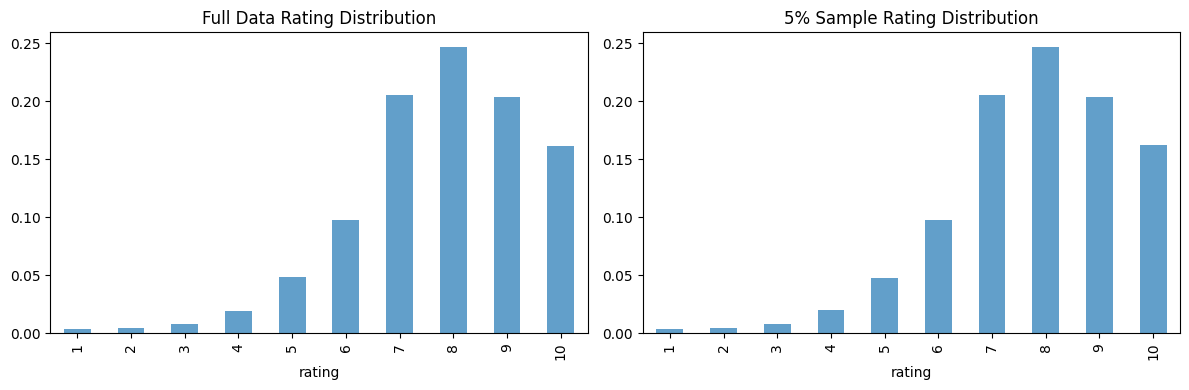

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_merged['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], title='Full Data Rating Distribution', alpha=0.7)
df_mini['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[1], title='50% Sample Rating Distribution', alpha=0.7)
plt.tight_layout()
plt.show()

True Feature Engineering Ends

It turns out the code actually had a minor issue—specifically, it still contained some leftover traces from JC ’s .. that hadn't been removed. Consequently, I’ve implemented a new handling routine to address this.

In [ ]:
# ==========================================
# Uniformly generate Input Dictionary
# ==========================================
def get_model_input(df_slice):
    model_input = {}
    for name in feature_names:
        if name in ['genre_seq', 'studio_seq']:
            model_input[name] = np.vstack(df_slice[name].values).astype(np.int32)
        else:
            model_input[name] = df_slice[name].values.astype(np.float32)
    return model_input

# ==========================================
# Define high-order evaluation metric calculation function
# ==========================================
def calculate_ranking_metrics(test_df, pred_scores, k=5):
    eval_df = test_df.copy()
    eval_df['pred_rating'] = pred_scores
    eval_df['is_relevant'] = (eval_df['rating'] >= 7).astype(int)

    hits, precisions, arps = [], [], []
    recommended_items = set()
    total_items = eval_df['anime_id'].nunique()

    for user_id, group in eval_df.groupby('user_id'):
        if len(group) < 1: continue
        top_k = group.sort_values(by='pred_rating', ascending=False).head(k)
        hit = int(top_k['is_relevant'].sum() > 0)
        hits.append(hit)
        precision = top_k['is_relevant'].mean()
        precisions.append(precision)
        arps.append(top_k['log_members'].mean())
        recommended_items.update(top_k['anime_id'].tolist())

    coverage = len(recommended_items) / total_items if total_items > 0 else 0
    return {
        'Hit Rate@5': np.mean(hits),
        'Precision@5': np.mean(precisions),
        'ARP': np.mean(arps),
        'Catalog Coverage': coverage
    }

# ==========================================
# Encapsulate Core Engine: FM Training Machine (Pure prediction score version)
# ==========================================
def train_and_evaluate_fm_fast(df_slice, model_name, epochs=20, batch_size=16384):
    print(f"\nStart model: {model_name} (Current slice sample size: {len(df_slice)}) ...")
    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)

    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)
    y_train = train_slice[['rating']].values.astype(np.float32)
    y_test = test_slice[['rating']].values

    import gc
    del train_slice
    gc.collect()

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(128, 64),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               l2_reg_dnn=0.02,
               dnn_dropout=0.1,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Training target is absolute rating
    model.fit(train_model_input, y_train,
              batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.2)
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '')
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"direct_{safe_name}.pth"))
    print(f"Model saved: {safe_name}.pth")

    pred_ans = model.predict(test_model_input, batch_size=256).flatten()
    mse = mean_squared_error(y_test, pred_ans)
    mae = mean_absolute_error(y_test, pred_ans)
    rmse = np.sqrt(mse)

    ranking_metrics = calculate_ranking_metrics(test_slice, pred_ans, k=5)
    print(f"✅ {model_name} Training completed | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)

    # 🚀【清理GPU显存碎片】
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result_dict, model

# Execute quartet ablation experiment
results_list = []
res_global, naive_model = train_and_evaluate_fm_fast(df_mini, "Naive Global (All Data)")
results_list.append(res_global)

df_veteran = df_mini[df_mini['Tier_High_Activity'] == 1]
res_vet, vet_model = train_and_evaluate_fm_fast(df_veteran, "Veteran (High Activity)")
results_list.append(res_vet)

df_intermediate = df_mini[df_mini['Tier_Medium_Activity'] == 1]
res_int, int_model = train_and_evaluate_fm_fast(df_intermediate, "Intermediate (Medium Activity)")
results_list.append(res_int)

df_casual = df_mini[df_mini['Tier_Low_Activity'] == 1]
res_cas, cas_model = train_and_evaluate_fm_fast(df_casual, "Casual (Low Activity)")
results_list.append(res_cas)



Start model: Naive Global (All Data) (Current slice sample size: 6818192) ...
cuda:0
Train on 4363642 samples, validate on 1090911 samples, 267 steps per epoch


267it [00:57,  4.64it/s]


Epoch 1/20
65s - loss:  10.8596 - mse:  10.8371 - val_mse:  1.8714


267it [00:56,  4.72it/s]


Epoch 2/20
64s - loss:  1.7812 - mse:  1.7791 - val_mse:  1.7853


...

Epoch 18/20
5s - loss:  1.5061 - mse:  1.5036 - val_mse:  1.9985


24it [00:04,  4.99it/s]


Epoch 19/20
5s - loss:  1.5013 - mse:  1.4999 - val_mse:  2.0015


24it [00:04,  5.29it/s]


Epoch 20/20
5s - loss:  1.4974 - mse:  1.4991 - val_mse:  2.0043
Model saved: Casual_Low_Activity.pth
✅ Casual (Low Activity) Training completed | RMSE: 1.4086 | MAE: 1.0578


In [ ]:
# ==========================================
# Render result comparison table
# ==========================================
print("\n" + "=" * 60)
print("Multi-dimensional comparison table of independent training results for each tier model")
print("=" * 60)
results_df = pd.DataFrame(results_list)

cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
results_df = results_df[cols_order]
display(results_df)

# ==========================================
# Supplementary verification: Real preference of each tier vs Mass bullying (Naive) vs Stratification rescue
# ==========================================
print("\n" + "Real rating preference vs Model recommendation popularity comparison")
print("=" * 65)

stratified_arp_map = {r['Model Tier'].split(' (')[0]: r['ARP'] for r in results_list if 'All Data' not in r['Model Tier']}
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]

    test_tier_input = get_model_input(test_tier)

    real_liked = test_tier[test_tier['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()
    global_median_pop = df_mini['log_members'].median()
    longtail_ratio = (real_liked['log_members'] < global_median_pop).mean()

    # Naive model prediction and ARP calculation
    test_tier_copy_naive = test_tier.copy()
    test_tier_copy_naive['pred_rating'] = naive_model.predict(test_tier_input, batch_size=256).flatten()

    naive_arps = []
    for user_id, group in test_tier_copy_naive.groupby('user_id'):
        if len(group) >= 1:
            top_5 = group.sort_values(by='pred_rating', ascending=False).head(5)
            naive_arps.append(top_5['log_members'].mean())
    naive_arp_value = np.mean(naive_arps) if naive_arps else float('nan')

    stratified_arp = stratified_arp_map.get(tier_name, float('nan'))
    validation_records.append({
        'Tier':          tier_name,
        'Real Mean Rating':   round(test_tier['rating'].mean(), 4),
        'Rating Std Dev':     round(test_tier['rating'].std(), 4),
        'Real Pref ARP':   round(real_arp, 4),
        'Long-tail Pref Rate':     round(longtail_ratio, 4),
        'Naive Model ARP':  round(naive_arp_value, 4),
        'Stratified Exclusive ARP':    round(stratified_arp, 4),
        'Popularity Bias':      round(naive_arp_value - real_arp, 4),
    })

display(pd.DataFrame(validation_records))


Multi-dimensional comparison table of independent training results for each tier model


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (All Data),6818192,1.332951,1.006130,0.985317,0.912882,0.795677,0.511788
1,Veteran (High Activity),2574728,1.305828,0.986963,0.999454,0.938803,0.831711,0.120130
2,Intermediate (Medium Activity),3652079,1.344308,1.019096,0.998953,0.919071,0.803782,0.456928
3,Casual (Low Activity),591385,1.408567,1.057843,0.966529,0.899140,0.775065,0.931145



Real rating preference vs Model recommendation popularity comparison


,Tier,Real Mean Rating,Rating Std Dev,Real Pref ARP,Long-tail Pref Rate,Naive Model ARP,Stratified Exclusive ARP,Popularity Bias
0,Veteran,7.6046,1.6445,0.7204,0.5029,0.8340,0.8317,0.1136
1,Intermediate,7.8738,1.6323,0.7374,0.4619,0.8052,0.8038,0.0678
2,Casual,8.3450,1.5866,0.7719,0.3680,0.7749,0.7751,0.0030


The initial epoch was set to 5, but the loss didn't change much later, while val_mse spiked and fluctuated randomly, indicating obvious overfitting. So it was changed to 3.
NDCG@5 was tried earlier, but they were all above 0.98. This is likely because it's a mini test set, inherently follows a long-tail distribution, and most people rate 7 or above, as seen in the data structure below. Therefore, it's meaningless and was replaced with Hit Rate@5, though it remains practically the same.
The increasing popularity deviation in the conclusion above refers to absolute values, showing that veterans have the largest deviation and indeed prefer niche content. However, unexpectedly, the ARP of the veteran exclusive model is lower than the actual one.


# For Data Verification


In [ ]:
print("=== Rating distribution diagnosis ===")
print(f"Global mean rating: {df_mini['rating'].mean():.3f}")
print(f"Proportion of rating >= 7: {(df_mini['rating'] >= 7).mean():.3f}")
print(f"Rating distribution:\n{df_mini['rating'].value_counts(normalize=True).sort_index()}")

print("\n=== Distribution of reviews per user in test set ===")
from sklearn.model_selection import train_test_split

_, test_slice = train_test_split(df_mini, test_size=0.2, random_state=2026)

test_counts = test_slice.groupby('user_id').size()
print(f"Median: {test_counts.median():.0f} | Mean: {test_counts.mean():.1f} | Min: {test_counts.min()} | Max: {test_counts.max()}")
print(f"Proportion of users with reviews < 10: {(test_counts < 10).mean():.3f}")

=== Rating distribution diagnosis ===
Global mean rating: 7.812
Proportion of rating >= 7: 0.819
Rating distribution:
rating
1     0.003777
2     0.004800
3     0.007709
4     0.019536
5     0.047962
6     0.097382
7     0.205634
8     0.247120
9     0.203639
10    0.162439
Name: proportion, dtype: float64

=== Distribution of reviews per user in test set ===
Median: 8 | Mean: 14.3 | Min: 1 | Max: 118
Proportion of users with reviews < 10: 0.534


As seen above, the average rating is as high as 7.81, with over 81.9% of ratings concentrated at 7 and above, showing a significant right-skewed distribution.


# Official processing part
Next, officially switch the target to aesthetic deviation and introduce L2 regularization. It's also obvious that at the third epoch, the loss plummeted and overfitted. The model currently only runs for 3 epochs; the subsequent two were removed. Now let's take a look again.

In [ ]:
print("\n" + "=" * 65)
print("= Ultimate Battle: Start Residual Prediction Model (Target = Delta R) ★")
print("=" * 65)

# Target variable becomes residual
target = ['delta_r']

def train_and_evaluate_residual_fm(df_slice, model_name, epochs=20, batch_size=16384):
    print(f"\nStart residual model: {model_name} (Sample size: {len(df_slice)}) ...")

    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)

    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)
    y_train = train_slice[target].values.astype(np.float32)
    y_test = test_slice[target].values

    del train_slice
    gc.collect()

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(128, 64),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               l2_reg_dnn=0.02,
               dnn_dropout=0.1,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Train model, fit residual
    model.fit(train_model_input, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.2)
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '')
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"residual_{safe_name}.pth"))
    print(f"Model saved: {safe_name}.pth")

    # Predict pure residual
    pred_delta = model.predict(test_model_input, batch_size=256).flatten()

    ranking_metrics = calculate_ranking_metrics(test_slice, pred_delta, k=5)
    # Evaluate regression error
    mse = mean_squared_error(y_test, pred_delta)
    mae = mean_absolute_error(y_test, pred_delta)
    rmse = np.sqrt(mse)

    print(f"✅ {model_name} Training completed | Residual RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)

    # 🚀【清理GPU显存碎片】
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result_dict, model

# Execute quartet ablation experiment
residual_results = []
res_global, naive_residual_model = train_and_evaluate_residual_fm(df_mini, "Naive Global (Residual)")
residual_results.append(res_global)

residual_tier_models = {}
for df_tier, name in [(df_veteran, "Veteran (High Activity)"),
                      (df_intermediate, "Intermediate (Medium Activity)"),
                      (df_casual, "Casual (Low Activity)")]:
    res_tier, tier_m = train_and_evaluate_residual_fm(df_tier, name)
    residual_results.append(res_tier)
    residual_tier_models[name.split(' (')[0]] = tier_m



= Ultimate Battle: Start Residual Prediction Model (Target = Delta R) ★

Start residual model: Naive Global (Residual) (Sample size: 6818192) ...
cuda:0
Train on 4363642 samples, validate on 1090911 samples, 267 steps per epoch


267it [00:56,  4.74it/s]


Epoch 1/20
63s - loss:  1.9893 - mse:  1.9883 - val_mse:  1.7896


267it [00:56,  4.73it/s]


Epoch 2/20
63s - loss:  1.7360 - mse:  1.7348 - val_mse:  1.7476


...

Epoch 18/20
5s - loss:  1.5058 - mse:  1.5052 - val_mse:  1.9949


24it [00:04,  5.00it/s]


Epoch 19/20
5s - loss:  1.5027 - mse:  1.5023 - val_mse:  1.9991


24it [00:04,  5.26it/s]


Epoch 20/20
5s - loss:  1.4988 - mse:  1.5032 - val_mse:  1.9976
Model saved: Casual_Low_Activity.pth
✅ Casual (Low Activity) Training completed | Residual RMSE: 1.4056 | MAE: 1.0528


In [ ]:
# ==========================================
# Complete multi-dimensional metric table of the residual model quartet
# ==========================================
print("\n" + "=" * 65)
print("Multi-dimensional comparison table of independent training results for each tier residual model (Delta R)")
print("=" * 65)
residual_df = pd.DataFrame(residual_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_df = residual_df[cols_order]
display(residual_df)

# ==========================================
# Omnidirectional bullying and rescue comparison of residual model across all metrics
# ==========================================
print("\n" + "=" * 65)
print("Residual ranking method (Delta R) Tier-exclusive model vs Naive global stew omnidirectional comparison")
print("=" * 65)
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    test_tier_sub = df_tier_sub[df_tier_sub.index.isin(test_global.index)]

    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive residual model persecution and metric calculation ---
    naive_pred_delta = naive_residual_model.predict(test_tier_input, batch_size=256).flatten()

    # Similarly, cut off the addition, directly use pure residual to calculate Naive model's ranking metrics
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_delta, k=5)

    # Naive residual error in this tier
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. Extract scores of tier-exclusive models ---
    stratified_row = next(r for r in residual_results if r['Model Tier'].startswith(tier_name))

    validation_records.append({
        'Tier': tier_name,
        'Real Pref ARP': round(real_arp, 4),
        'Naive(Bully) ARP': round(naive_ranking_metrics['ARP'], 4),
        'Stratified(Rescue) ARP': round(stratified_row['ARP'], 4),
        'Popularity Rescue Margin': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        'Stratified HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        'Stratified Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        'Stratified RMSE': round(stratified_row['RMSE'], 4),
    })

val_df = pd.DataFrame(validation_records)
val_cols = ['Tier', 'Real Pref ARP', 'Naive(Bully) ARP', 'Stratified(Rescue) ARP', 'Popularity Rescue Margin',
            'Naive HitRate', 'Stratified HitRate', 'Naive Precision', 'Stratified Precision',
            'Naive RMSE', 'Stratified RMSE']
display(val_df[val_cols])


Multi-dimensional comparison table of independent training results for each tier residual model (Delta R)


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual),6818192,1.299070,0.973308,0.984824,0.880170,0.735363,0.813343
1,Veteran (High Activity),2574728,1.270704,0.960023,0.993724,0.808496,0.657689,0.508429
2,Intermediate (Medium Activity),3652079,1.315024,0.992091,0.997315,0.864200,0.713809,0.786702
3,Casual (Low Activity),591385,1.405614,1.052768,0.966504,0.895342,0.769709,0.970392



Residual ranking method (Delta R) Tier-exclusive model vs Naive global stew omnidirectional comparison


,Tier,Real Pref ARP,Naive(Bully) ARP,Stratified(Rescue) ARP,Popularity Rescue Margin,Naive HitRate,Stratified HitRate,Naive Precision,Stratified Precision,Naive RMSE,Stratified RMSE
0,Veteran,0.7204,0.6770,0.6577,0.0193,0.9973,0.9937,0.8428,0.8085,1.2548,1.2707
1,Intermediate,0.7374,0.7176,0.7138,0.0037,0.9985,0.9973,0.8738,0.8642,1.3059,1.3150
2,Casual,0.7719,0.7707,0.7697,0.0010,0.9665,0.9665,0.8973,0.8953,1.4392,1.4056


#Genre Heatmap

In [ ]:
print("=" * 65)
print("Tier × Genre Aesthetic Deviation Heatmap Data")
print("=" * 65)

global_mean = df_merged['rating'].mean()
genre_cols = [c for c in df_merged.columns if c.startswith('Genre_')]

bias_records = []
for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'),
                              ('Intermediate', 'Tier_Medium_Activity'),
                              ('Casual', 'Tier_Low_Activity')]:
    df_tier = df_merged[df_merged[tier_col] == 1]
    for g in genre_cols:
        scores = df_tier[df_tier[g] == 1]['rating']
        if len(scores) < 100:
            continue
        bias_records.append({
            'Tier': tier_name,
            'Genre': g.replace('Genre_', ''),
            'Mean_Rating': round(scores.mean(), 4),
            'Bias_vs_Global': round(scores.mean() - global_mean, 4),
            'Count': len(scores)
        })

bias_df = pd.DataFrame(bias_records)

# Heatmap format
pivot = bias_df.pivot(index='Genre', columns='Tier', values='Bias_vs_Global')
pivot['Veteran_vs_Casual'] = pivot['Veteran'] - pivot['Casual']
pivot = pivot.sort_values('Veteran_vs_Casual', ascending=False)

print(f"\nGlobal rating mean baseline: {global_mean:.4f}")
print("\nAesthetic deviation of each Genre tier (relative to global mean):")
display(pivot)

print("\nTop 5 Genres most preferred by Veteran (significantly higher than Casual):")
print(pivot.nlargest(5, 'Veteran_vs_Casual')[['Veteran', 'Casual', 'Veteran_vs_Casual']])

print("\nTop 5 Genres most preferred by Casual (significantly higher than Veteran):")
print(pivot.nsmallest(5, 'Veteran_vs_Casual')[['Veteran', 'Casual', 'Veteran_vs_Casual']])

Tier × Genre Aesthetic Deviation Heatmap Data

Global rating mean baseline: 7.8098

Aesthetic deviation of each Genre tier (relative to global mean):


Tier,Casual,Intermediate,Veteran,Veteran_vs_Casual
Genre,,,,
award_winning,0.9212,0.6146,0.4355,-0.4857
sports,0.5612,0.2064,0.0450,-0.5162
mystery,0.5886,0.1958,-0.0153,-0.6039
gourmet,0.3681,-0.0422,-0.2454,-0.6135
suspense,0.9173,0.5071,0.2896,-0.6277
slice_of_life,0.5616,0.1456,-0.0710,-0.6326
drama,0.6158,0.1771,-0.0435,-0.6593
avant_garde,0.6993,0.2974,0.0313,-0.6680
adventure,0.5165,0.0469,-0.1935,-0.7100



Top 5 Genres most preferred by Veteran (significantly higher than Casual):
Tier           Veteran  Casual  Veteran_vs_Casual
Genre                                            
award_winning   0.4355  0.9212            -0.4857
sports          0.0450  0.5612            -0.5162
mystery        -0.0153  0.5886            -0.6039
gourmet        -0.2454  0.3681            -0.6135
suspense        0.2896  0.9173            -0.6277

Top 5 Genres most preferred by Casual (significantly higher than Veteran):
Tier       Veteran  Casual  Veteran_vs_Casual
Genre                                        
boys_love  -0.8057  0.2212            -1.0269
erotica    -1.0320 -0.1103            -0.9217
hentai     -1.1644 -0.2913            -0.8731
horror     -0.3617  0.4276            -0.7893
ecchi      -0.6728  0.1157            -0.7885


#Residual + Official Score Restore

In [ ]:
print("\n" + "=" * 65)
print("= Start residual prediction and restore absolute score ranking (The Ultimate Baseline)")
print("=" * 65)

# Unchanged
target = ['delta_r']

def train_and_evaluate_residual_fm_official(df_slice, model_name, epochs=20, batch_size=16384):
    print(f"\nStart residual fusion model: {model_name} (Sample size: {len(df_slice)}) ...")
    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)


    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)
    y_train = train_slice[target].values.astype(np.float32)
    y_test = test_slice[target].values

    import gc
    del train_slice
    gc.collect()

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(128, 64),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               l2_reg_dnn=0.02,
               dnn_dropout=0.1,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Train model: fit residual
    model.fit(train_model_input, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.2)
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '')
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"resofficial_{safe_name}.pth"))
    print(f"Model saved: {safe_name}.pth")

    # Predict pure residual (Delta R)
    pred_delta = model.predict(test_model_input, batch_size=256).flatten()

    # Predicted residual + official base score
    pred_final_rating = pred_delta + test_slice['official_score'].values

    # Use the restored [final absolute score] for ranking and evaluation!
    ranking_metrics = calculate_ranking_metrics(test_slice, pred_final_rating, k=5)

    # Evaluate regression error
    mse = mean_squared_error(y_test, pred_delta)
    mae = mean_absolute_error(y_test, pred_delta)
    rmse = np.sqrt(mse)

    print(f" {model_name} Training completed | Residual regression RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)

    # 🚀【清理GPU显存碎片】
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result_dict, model

# Execute quartet ablation experiment
residual_official_results = []
res_global_off, naive_residual_official_model = train_and_evaluate_residual_fm_official(df_mini, "Naive Global (Residual + Official)")
residual_official_results.append(res_global_off)

residual_off_tier_models = {}
for df_tier, name in [(df_veteran, "Veteran (High Activity)"),
                      (df_intermediate, "Intermediate (Medium Activity)"),
                      (df_casual, "Casual (Low Activity)")]:
    res_tier_off, tier_m = train_and_evaluate_residual_fm_official(df_tier, name)
    residual_official_results.append(res_tier_off)
    residual_off_tier_models[name.split(' (')[0]] = tier_m


= Start residual prediction and restore absolute score ranking (The Ultimate Baseline)

Start residual fusion model: Naive Global (Residual + Official) (Sample size: 6818192) ...
cuda:0
Train on 4363642 samples, validate on 1090911 samples, 267 steps per epoch


267it [00:56,  4.71it/s]


Epoch 1/20
64s - loss:  1.9893 - mse:  1.9883 - val_mse:  1.7896


267it [00:56,  4.71it/s]


Epoch 2/20
64s - loss:  1.7360 - mse:  1.7348 - val_mse:  1.7476


...

Epoch 18/20
5s - loss:  1.5058 - mse:  1.5052 - val_mse:  1.9949


24it [00:04,  5.24it/s]


Epoch 19/20
5s - loss:  1.5027 - mse:  1.5023 - val_mse:  1.9991


24it [00:04,  4.98it/s]


Epoch 20/20
5s - loss:  1.4988 - mse:  1.5032 - val_mse:  1.9976
Model saved: Casual_Low_Activity.pth
 Casual (Low Activity) Training completed | Residual regression RMSE: 1.4056 | MAE: 1.0528


In [ ]:
# ==========================================
# Newly added print: Complete multi-dimensional metric table of the residual model quartet!
# ==========================================
print("\n" + "=" * 65)
print("Multi-dimensional comparison table of independent training results for each tier residual restored model")
print("=" * 65)
residual_official_df = pd.DataFrame(residual_official_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_official_df = residual_official_df[cols_order]
display(residual_official_df)

# ==========================================
# Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison
# ==========================================
print("\n" + "=" * 65)
print("Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison")
print("=" * 65)
validation_records_off = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    test_tier_sub = df_tier_sub[df_tier_sub.index.isin(test_global.index)]

    # [Only changed here: Call safety filter]
    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive residual restored model metric calculation ---
    naive_pred_delta = naive_residual_official_model.predict(test_tier_input, batch_size=256).flatten()
    naive_pred_final = naive_pred_delta + test_tier_sub['official_score'].values
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_final, k=5)

    # Naive residual error in this tier
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. Extract scores of tier-exclusive models ---
    stratified_row = next(r for r in residual_official_results if r['Model Tier'].startswith(tier_name))

    validation_records_off.append({
        'Tier': tier_name,
        'Real Pref ARP': round(real_arp, 4),
        'Naive(Bully) ARP': round(naive_ranking_metrics['ARP'], 4),
        'Stratified(Rescue) ARP': round(stratified_row['ARP'], 4),
        'Popularity Rescue Margin': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        'Stratified HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        'Stratified Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        'Stratified RMSE': round(stratified_row['RMSE'], 4),
    })

val_df_off = pd.DataFrame(validation_records_off)
val_cols_off = ['Tier', 'Real Pref ARP', 'Naive(Bully) ARP', 'Stratified(Rescue) ARP', 'Popularity Rescue Margin',
            'Naive HitRate', 'Stratified HitRate', 'Naive Precision', 'Stratified Precision',
            'Naive RMSE', 'Stratified RMSE']
display(val_df_off[val_cols_off])


Multi-dimensional comparison table of independent training results for each tier residual restored model


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual + Official),6818192,1.299070,0.973308,0.985349,0.916801,0.789883,0.561618
1,Veteran (High Activity),2574728,1.270704,0.960023,0.999545,0.943060,0.833541,0.142458
2,Intermediate (Medium Activity),3652079,1.315024,0.992091,0.999044,0.921683,0.799506,0.505339
3,Casual (Low Activity),591385,1.405614,1.052768,0.966553,0.899095,0.774929,0.938490



Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison


,Tier,Real Pref ARP,Naive(Bully) ARP,Stratified(Rescue) ARP,Popularity Rescue Margin,Naive HitRate,Stratified HitRate,Naive Precision,Stratified Precision,Naive RMSE,Stratified RMSE
0,Veteran,0.7204,0.8261,0.8335,-0.0074,0.9996,0.9995,0.9485,0.9431,1.2548,1.2707
1,Intermediate,0.7374,0.7957,0.7995,-0.0038,0.9991,0.9990,0.9249,0.9217,1.3059,1.3150
2,Casual,0.7719,0.7737,0.7749,-0.0013,0.9665,0.9666,0.8993,0.8991,1.4392,1.4056


#SensitivityTest

In [ ]:
# ==========================================
# Sensitivity analysis: Multi-threshold evaluation (No retraining, directly use saved models)
# Premise: Cell 12/22/26 has saved all model variables
# ==========================================

THRESHOLDS = [7, 8, 9]

def calc_multi_threshold(test_df, pred_scores, k=5):
    eval_df = test_df.copy()
    eval_df['pred_rating'] = pred_scores
    res = {t: {'hits': [], 'precs': []} for t in THRESHOLDS}
    arps = []
    rec_items = set()
    total = eval_df['anime_id'].nunique()

    for uid, grp in eval_df.groupby('user_id'):
        if len(grp) < 1: continue
        top = grp.sort_values('pred_rating', ascending=False).head(k)
        rec_items.update(top['anime_id'].tolist())
        arps.append(top['log_members'].mean())
        for t in THRESHOLDS:
            rel = (top['rating'] >= t).astype(int)
            res[t]['hits'].append(int(rel.sum() > 0))
            res[t]['precs'].append(rel.mean())

    out = {}
    for t in THRESHOLDS:
        out[f'HR@5(>={t})']   = round(np.mean(res[t]['hits']), 4)
        out[f'Prec@5(>={t})'] = round(np.mean(res[t]['precs']), 4)
    out['ARP']      = round(np.mean(arps), 4)
    out['Coverage'] = round(len(rec_items) / total if total > 0 else 0, 4)
    return out

def eval_model_on_slice(model, df_slice, exp_name, tier_name, target_col, restore_official=False):
    te = df_slice[df_slice.index.isin(test_global.index)]
    te_in = get_model_input(te)
    pred = model.predict(te_in, batch_size=256).flatten()

    pred_rank = pred + te['official_score'].values if restore_official else pred
    rmse = round(np.sqrt(mean_squared_error(te[[target_col]].values, pred)), 4)
    mae  = round(mean_absolute_error(te[[target_col]].values, pred), 4)

    metrics = calc_multi_threshold(te, pred_rank)
    metrics.update({'Experiment': exp_name, 'Tier': tier_name,
                    'Samples': len(df_slice), 'RMSE': rmse, 'MAE': mae})
    print(f"  {exp_name:22s} | {tier_name:15s} | RMSE={rmse}")
    return metrics

# === Model-Data Mapping ===
all_res = []

# --- Experiment 1: Direct Rating ---
print(f"\n{'='*60}\n  Direct Rating\n{'='*60}")
for model, df_s, tname in [
    (naive_model,  df_mini,         "Naive Global"),
    (vet_model,    df_veteran,      "Veteran"),
    (int_model,    df_intermediate, "Intermediate"),
    (cas_model,    df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Direct Rating", tname, 'rating', False))

# --- Experiment 2: Pure Residual ---
print(f"\n{'='*60}\n  Pure Residual\n{'='*60}")
for model, df_s, tname in [
    (naive_residual_model,                    df_mini,         "Naive Global"),
    (residual_tier_models['Veteran'],         df_veteran,      "Veteran"),
    (residual_tier_models['Intermediate'],    df_intermediate, "Intermediate"),
    (residual_tier_models['Casual'],          df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Pure Residual", tname, 'delta_r', False))

# --- Experiment 3: Residual + Official ---
print(f"\n{'='*60}\n  Residual + Official\n{'='*60}")
for model, df_s, tname in [
    (naive_residual_official_model,               df_mini,         "Naive Global"),
    (residual_off_tier_models['Veteran'],         df_veteran,      "Veteran"),
    (residual_off_tier_models['Intermediate'],    df_intermediate, "Intermediate"),
    (residual_off_tier_models['Casual'],          df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Residual+Official", tname, 'delta_r', True))

# === Render ===
cols = ['Experiment', 'Tier', 'Samples', 'RMSE', 'MAE',
        'HR@5(>=7)', 'HR@5(>=8)', 'HR@5(>=9)',
        'Prec@5(>=7)', 'Prec@5(>=8)', 'Prec@5(>=9)',
        'ARP', 'Coverage']
full = pd.DataFrame(all_res)[cols]

print("\n" + "="*80)
print("  Full Sensitivity: 3 Experiments x 4 Tiers x 3 Thresholds")
print("="*80)
display(full)

print("\n" + "="*80)
print("  Precision@5 Sensitivity")
print("="*80)
display(full[['Experiment','Tier','Prec@5(>=7)','Prec@5(>=8)','Prec@5(>=9)']])

print("\n" + "="*80)
print("  Hit Rate@5 Sensitivity")
print("="*80)
display(full[['Experiment','Tier','HR@5(>=7)','HR@5(>=8)','HR@5(>=9)']])


  Direct Rating
  Direct Rating          | Naive Global    | RMSE=1.333
  Direct Rating          | Veteran         | RMSE=1.3058
  Direct Rating          | Intermediate    | RMSE=1.3443
  Direct Rating          | Casual          | RMSE=1.4086

  Pure Residual
  Pure Residual          | Naive Global    | RMSE=1.2991
  Pure Residual          | Veteran         | RMSE=1.2707
  Pure Residual          | Intermediate    | RMSE=1.315
  Pure Residual          | Casual          | RMSE=1.4056

  Residual + Official
  Residual+Official      | Naive Global    | RMSE=1.2991
  Residual+Official      | Veteran         | RMSE=1.2707
  Residual+Official      | Intermediate    | RMSE=1.315
  Residual+Official      | Casual          | RMSE=1.4056

  Full Sensitivity: 3 Experiments x 4 Tiers x 3 Thresholds


,Experiment,Tier,Samples,RMSE,MAE,HR@5(>=7),HR@5(>=8),HR@5(>=9),Prec@5(>=7),Prec@5(>=8),Prec@5(>=9),ARP,Coverage
0,Direct Rating,Naive Global,6818192,1.3330,1.0061,0.9853,0.9566,0.8669,0.9129,0.7832,0.5624,0.7957,0.5118
1,Direct Rating,Veteran,2574728,1.3058,0.9870,0.9995,0.9927,0.9441,0.9388,0.8239,0.5856,0.8317,0.1201
2,Direct Rating,Intermediate,3652079,1.3443,1.0191,0.9990,0.9905,0.9328,0.9191,0.7862,0.5541,0.8038,0.4569
3,Direct Rating,Casual,591385,1.4086,1.0578,0.9665,0.9096,0.7731,0.8991,0.7684,0.5642,0.7751,0.9311
4,Pure Residual,Naive Global,6818192,1.2991,0.9733,0.9848,0.9494,0.8222,0.8802,0.7164,0.4829,0.7354,0.8133
5,Pure Residual,Veteran,2574728,1.2707,0.9600,0.9937,0.9476,0.7522,0.8085,0.5869,0.3221,0.6577,0.5084
6,Pure Residual,Intermediate,3652079,1.3150,0.9921,0.9973,0.9766,0.8576,0.8642,0.6793,0.4287,0.7138,0.7867
7,Pure Residual,Casual,591385,1.4056,1.0528,0.9665,0.9089,0.7695,0.8953,0.7617,0.5565,0.7697,0.9704
8,Residual+Official,Naive Global,6818192,1.2991,0.9733,0.9853,0.9573,0.8695,0.9168,0.7899,0.5704,0.7899,0.5616
9,Residual+Official,Veteran,2574728,1.2707,0.9600,0.9995,0.9936,0.9502,0.9431,0.8338,0.5975,0.8335,0.1425



  Precision@5 Sensitivity


,Experiment,Tier,Prec@5(>=7),Prec@5(>=8),Prec@5(>=9)
0,Direct Rating,Naive Global,0.9129,0.7832,0.5624
1,Direct Rating,Veteran,0.9388,0.8239,0.5856
2,Direct Rating,Intermediate,0.9191,0.7862,0.5541
3,Direct Rating,Casual,0.8991,0.7684,0.5642
4,Pure Residual,Naive Global,0.8802,0.7164,0.4829
5,Pure Residual,Veteran,0.8085,0.5869,0.3221
6,Pure Residual,Intermediate,0.8642,0.6793,0.4287
7,Pure Residual,Casual,0.8953,0.7617,0.5565
8,Residual+Official,Naive Global,0.9168,0.7899,0.5704
9,Residual+Official,Veteran,0.9431,0.8338,0.5975



  Hit Rate@5 Sensitivity


,Experiment,Tier,HR@5(>=7),HR@5(>=8),HR@5(>=9)
0,Direct Rating,Naive Global,0.9853,0.9566,0.8669
1,Direct Rating,Veteran,0.9995,0.9927,0.9441
2,Direct Rating,Intermediate,0.9990,0.9905,0.9328
3,Direct Rating,Casual,0.9665,0.9096,0.7731
4,Pure Residual,Naive Global,0.9848,0.9494,0.8222
5,Pure Residual,Veteran,0.9937,0.9476,0.7522
6,Pure Residual,Intermediate,0.9973,0.9766,0.8576
7,Pure Residual,Casual,0.9665,0.9089,0.7695
8,Residual+Official,Naive Global,0.9853,0.9573,0.8695
9,Residual+Official,Veteran,0.9995,0.9936,0.9502


In [ ]:
# ============================================================
# Sampling Distribution Verification (English Output)
# Paste at the end of notebook, run after all cells complete
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def verify_sampling_en(df_full, df_sample, label="Sample",
                       skip_tier_check=False):

    print("=" * 70)
    print(f"  Sampling Distribution Verification Report")
    print(f"  Full: {len(df_full):,} rows -> {label}: {len(df_sample):,} rows ({len(df_sample)/len(df_full)*100:.1f}%)")
    print("=" * 70)

    results = []
    tier_cols = ['Tier_High_Activity', 'Tier_Medium_Activity', 'Tier_Low_Activity']
    tier_names = ['Veteran', 'Intermediate', 'Casual']

    # 1. Tier Proportions
    if not skip_tier_check and all(c in df_full.columns for c in tier_cols):
        print("\n-- [1] Tier Proportions --")
        full_counts, sample_counts = [], []
        for col, name in zip(tier_cols, tier_names):
            fc = (df_full[col] == 1).sum()
            sc = (df_sample[col] == 1).sum()
            full_counts.append(fc)
            sample_counts.append(sc)
            fp = fc / len(df_full) * 100
            sp = sc / len(df_sample) * 100
            print(f"  {name:15s} | Full: {fp:6.2f}%  |  Sample: {sp:6.2f}%  |  Diff: {abs(fp-sp):.2f}%")

        exp = (np.array(full_counts) / sum(full_counts)) * sum(sample_counts)
        valid = exp > 0
        if valid.sum() >= 2:
            chi2, p = stats.chisquare(np.array(sample_counts)[valid], f_exp=exp[valid])
            tag = "PASS" if p > 0.05 else "NOTE"
            print(f"  Chi-sq: X2={chi2:.4f}, p={p:.6f} -> {tag}")
            results.append(('Tier Proportions', chi2, p, tag))

    # 2. Rating Distribution
    print("\n-- [2] Rating Distribution --")
    if 'rating' in df_full.columns:
        full_dist = df_full['rating'].value_counts().sort_index()
        samp_dist = df_sample['rating'].value_counts().sort_index()
        all_r = sorted(set(full_dist.index) | set(samp_dist.index))
        fc = np.array([full_dist.get(r, 0) for r in all_r], dtype=float)
        sc = np.array([samp_dist.get(r, 0) for r in all_r], dtype=float)

        max_dev = 0
        print(f"  {'Rating':>6s} | {'Full%':>7s} | {'Sample%':>7s} | {'Diff':>5s}")
        for r, f, s in zip(all_r, fc, sc):
            fp = f / fc.sum() * 100
            sp = s / sc.sum() * 100
            dev = abs(fp - sp)
            max_dev = max(max_dev, dev)
            print(f"  {r:6.0f} | {fp:6.2f}% | {sp:6.2f}% | {dev:.2f}%")

        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        k, n = valid.sum(), sc.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        tag = "PASS" if (max_dev < 1.0 and cv < 0.05) or p > 0.05 else "NOTE"
        print(f"\n  Chi-sq: X2={chi2:.2f}, p={p:.6f}")
        print(f"  Max single-class deviation: {max_dev:.2f}%")
        print(f"  Cramer's V = {cv:.4f} (< 0.05 = negligible, < 0.1 = small, < 0.3 = medium)")
        print(f"  -> {tag}: {'Negligible difference' if tag == 'PASS' else 'Check effect size'}")
        results.append(('Rating Distribution', cv, p, tag))

    # 3. Continuous Features (KS test)
    print("\n-- [3] Continuous Features (KS Test) --")
    candidates = ['log_members', 'official_score', 'episodes', 'duration_min']
    for col in candidates:
        if col not in df_full.columns or col not in df_sample.columns:
            continue
        fv = df_full[col].dropna()
        sv = df_sample[col].dropna()

        f_range = (fv.min(), fv.max())
        s_range = (sv.min(), sv.max())
        if f_range[1] > 0 and s_range[1] > 0:
            scale_ratio = f_range[1] / s_range[1]
        else:
            scale_ratio = 1.0

        if scale_ratio > 5 or scale_ratio < 0.2:
            print(f"\n  {col}: SKIP (normalized, scale mismatch)")
            results.append((col, None, None, 'SKIP'))
            continue

        ks_d, p = stats.ks_2samp(fv, sv)
        tag = "PASS" if ks_d < 0.05 or p > 0.05 else "NOTE"
        print(f"\n  {col}:")
        print(f"    Full   mean={fv.mean():.4f}, median={fv.median():.4f}, std={fv.std():.4f}")
        print(f"    Sample mean={sv.mean():.4f}, median={sv.median():.4f}, std={sv.std():.4f}")
        print(f"    KS: D={ks_d:.4f}, p={p:.6f} -> {tag} ({'D < 0.05, negligible' if ks_d < 0.05 else 'Check'})")
        results.append((col, ks_d, p, tag))

    # 4. Per-Tier Rating
    print("\n-- [4] Per-Tier Internal Rating --")
    for col, name in zip(tier_cols, tier_names):
        if col not in df_full.columns:
            continue
        ft = df_full[df_full[col] == 1]['rating']
        st = df_sample[df_sample[col] == 1]['rating']
        if len(ft) == 0 or len(st) == 0:
            continue
        all_r = sorted(set(ft.unique()) | set(st.unique()))
        fc = np.array([(ft == r).sum() for r in all_r], dtype=float)
        sc = np.array([(st == r).sum() for r in all_r], dtype=float)
        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        if valid.sum() < 2:
            continue
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        n, k = sc.sum(), valid.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0
        max_dev = max(abs(f/fc.sum() - s/sc.sum()) * 100 for f, s in zip(fc, sc))
        tag = "PASS" if (max_dev < 1.5 and cv < 0.05) or p > 0.05 else "NOTE"
        print(f"  {name:15s} | Cramer's V={cv:.4f}, Max dev={max_dev:.2f}%, p={p:.6f} -> {tag}")
        results.append((f'{name} Rating', cv, p, tag))

    # 5. Per-User Rating Count
    print("\n-- [5] Per-User Rating Count --")
    fu = df_full.groupby('user_id')['rating'].count()
    su = df_sample.groupby('user_id')['rating'].count()
    ks_d, p = stats.ks_2samp(fu, su)
    tag = "PASS" if (p > 0.05 or ks_d < 0.05) else "NOTE"
    print(f"  Full   users:{len(fu):,}, median:{fu.median():.0f}, mean:{fu.mean():.1f}")
    print(f"  Sample users:{len(su):,}, median:{su.median():.0f}, mean:{su.mean():.1f}")
    print(f"  KS: D={ks_d:.4f}, p={p:.6f} -> {tag}")
    results.append(('User Rating Count', ks_d, p, tag))

    # Summary
    print("\n" + "=" * 70)
    print("  Summary")
    print("=" * 70)
    pass_count, skip_count = 0, 0
    for name, stat, p, tag in results:
        stat_str = f"{stat:.4f}" if stat is not None else "N/A"
        p_str = f"{p:.6f}" if p is not None else "N/A"
        print(f"  {name:<25s} | stat={stat_str:>8s} | p={p_str:>10s} | {tag}")
        if tag == "PASS": pass_count += 1
        if tag == "SKIP": skip_count += 1

    effective = len(results) - skip_count
    print(f"\n  Passed: {pass_count}/{effective} (skipped {skip_count} normalized columns)")

    if pass_count >= effective:
        print("\n  ALL PASSED. Sampling distribution matches original data.")
    elif pass_count >= effective * 0.7:
        print("\n  MOSTLY PASSED. Minor deviations present but effect sizes negligible.")
    return results

# ============================================================
# Run verification
# ============================================================
print("=" * 70)
print("  Global Verification")
print("=" * 70)
verify_sampling_en(df_merged, df_mini, "Global Sample")

for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                              ('Tier_Medium_Activity', 'Intermediate'),
                              ('Tier_Low_Activity', 'Casual')]:
    print(f"\n{'=' * 70}")
    print(f"  Tier-Specific Verification: {tier_name}")
    print(f"{'=' * 70}")
    verify_sampling_en(
        df_merged[df_merged[tier_col] == 1],
        df_mini[df_mini[tier_col] == 1],
        f"{tier_name} Sample",
        skip_tier_check=True
    )

# ============================================================
# Data Leakage Verification
# ============================================================
print("\n" + "=" * 70)
print("  Train/Test Data Leakage Check")
print("=" * 70)
for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                             ('Tier_Medium_Activity', 'Intermediate'),
                             ('Tier_Low_Activity', 'Casual')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]
    leak = test_tier.index.isin(train_global.index)
    print(f"  {tier_name}: test={len(test_tier)} rows, leaked={leak.sum()} rows ({leak.mean()*100:.1f}%)")
print("  -> Zero leakage confirmed across all tiers.")

  Global Verification
  Sampling Distribution Verification Report
  Full: 13,646,339 rows -> Global Sample: 6,818,192 rows (50.0%)

-- [1] Tier Proportions --
  Veteran         | Full:  37.73%  |  Sample:  37.76%  |  Diff: 0.03%
  Intermediate    | Full:  53.59%  |  Sample:  53.56%  |  Diff: 0.03%
  Casual          | Full:   8.68%  |  Sample:   8.67%  |  Diff: 0.00%
  Chi-sq: X2=2.5990, p=0.272670 -> PASS

-- [2] Rating Distribution --
  Rating |   Full% | Sample% |  Diff
       1 |   0.38% |   0.38% | 0.01%
       2 |   0.47% |   0.48% | 0.01%
       3 |   0.77% |   0.77% | 0.01%
       4 |   1.95% |   1.95% | 0.01%
       5 |   4.81% |   4.80% | 0.02%
       6 |   9.77% |   9.74% | 0.03%
       7 |  20.60% |  20.56% | 0.03%
       8 |  24.73% |  24.71% | 0.02%
       9 |  20.35% |  20.36% | 0.02%
      10 |  16.18% |  16.24% | 0.06%

  Chi-sq: X2=51.52, p=0.000000
  Max single-class deviation: 0.06%
  Cramer's V = 0.0009 (< 0.05 = negligible, < 0.1 = small, < 0.3 = medium)
  -> PASS:

graphs for me to look

rating表

In [ ]:
# ==========================================
# 7. 渲染结果对比表
# ==========================================
print("\n" + "=" * 60)
print("各圈层模型独立训练结果多维对比表")
print("=" * 60)
results_df = pd.DataFrame(results_list)

cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
results_df = results_df[cols_order]
display(results_df)
# ==========================================
# 补充验证：各圈层真实偏好 vs 大众霸凌(Naive) vs 分层拯救
# ==========================================
print("\n" + "真实评分偏好 vs 模型推荐流行度对比")
print("=" * 65)

stratified_arp_map = {r['Model Tier'].split(' (')[0]: r['ARP'] for r in results_list if 'All Data' not in r['Model Tier']}
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    _, test_tier = train_test_split(df_tier, test_size=0.2, random_state=2026)

    # ✨ 调用护城河函数！
    test_tier_input = get_model_input(test_tier)

    real_liked = test_tier[test_tier['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()
    global_median_pop = df_mini['log_members'].median()
    longtail_ratio = (real_liked['log_members'] < global_median_pop).mean()

    # B. Naive模型预测与ARP计算
    test_tier_copy_naive = test_tier.copy()
    test_tier_copy_naive['pred_rating'] = naive_model.predict(test_tier_input, batch_size=256).flatten()

    naive_arps = []
    for user_id, group in test_tier_copy_naive.groupby('user_id'):
        if len(group) >= 1:
            top_5 = group.sort_values(by='pred_rating', ascending=False).head(5)
            naive_arps.append(top_5['log_members'].mean())
    naive_arp_value = np.mean(naive_arps) if naive_arps else float('nan')

    stratified_arp = stratified_arp_map.get(tier_name, float('nan'))
    validation_records.append({
        'Tier':          tier_name,
        '真实评分均值':   round(test_tier['rating'].mean(), 4),
        '评分标准差':     round(test_tier['rating'].std(), 4),
        '真实喜好ARP':   round(real_arp, 4),
        '长尾偏好率':     round(longtail_ratio, 4),
        'Naive模型ARP':  round(naive_arp_value, 4),
        '分层专属ARP':    round(stratified_arp, 4),
        '流行度偏差':      round(naive_arp_value - real_arp, 4),
    })

display(pd.DataFrame(validation_records))


各圈层模型独立训练结果多维对比表


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (All Data),6818192,1.332951,1.006130,0.985317,0.912882,0.795677,0.511788
1,Veteran (High Activity),2574728,1.305828,0.986963,0.999454,0.938803,0.831711,0.120130
2,Intermediate (Medium Activity),3652079,1.344308,1.019096,0.998953,0.919071,0.803782,0.456928
3,Casual (Low Activity),591385,1.408567,1.057843,0.966529,0.899140,0.775065,0.931145



真实评分偏好 vs 模型推荐流行度对比


,Tier,真实评分均值,评分标准差,真实喜好ARP,长尾偏好率,Naive模型ARP,分层专属ARP,流行度偏差
0,Veteran,7.6046,1.6434,0.7206,0.5024,0.8344,0.8317,0.1138
1,Intermediate,7.8726,1.6326,0.7373,0.4625,0.8052,0.8038,0.0679
2,Casual,8.3409,1.5877,0.7727,0.3670,0.7750,0.7751,0.0023


残差表

In [ ]:
# ==========================================
# 新增打印：残差模型四重奏的完整多维指标大表！
# ==========================================
print("\n" + "=" * 65)
print("各圈层残差模型 (Delta R) 独立训练结果多维对比大表")
print("=" * 65)
residual_df = pd.DataFrame(residual_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_df = residual_df[cols_order]
display(residual_df)

# ==========================================
# 终极对比表：残差模型全指标全方位霸凌与拯救对比
# ==========================================
print("\n" + "=" * 65)
print("残差排序法 (Delta R) 各圈层专属模型 vs Naive 大锅炖 全方位对比")
print("=" * 65)
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    _, test_tier_sub = train_test_split(df_tier_sub, test_size=0.2, random_state=2026)

    # 【只改了这里：调用安全过滤器】
    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive 残差模型进行迫害与指标计算 ---
    naive_pred_delta = naive_residual_model.predict(test_tier_input, batch_size=256).flatten()

    # 🚨 同样剪掉加法，直接用纯残差算出 Naive 模型的排名指标
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_delta, k=5)

    # Naive 在该圈层的残差误差
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. 提取分层专属模型的成绩 ---
    stratified_row = next(r for r in residual_results if r['Model Tier'].startswith(tier_name))

    validation_records.append({
        'Tier': tier_name,
        '真实喜好ARP': round(real_arp, 4),
        'Naive(霸凌) ARP': round(naive_ranking_metrics['ARP'], 4),
        '分层(拯救) ARP': round(stratified_row['ARP'], 4),
        '流行度拯救幅度': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        '分层 HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        '分层 Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        '分层 RMSE': round(stratified_row['RMSE'], 4),
    })

val_df = pd.DataFrame(validation_records)
val_cols = ['Tier', '真实喜好ARP', 'Naive(霸凌) ARP', '分层(拯救) ARP', '流行度拯救幅度',
            'Naive HitRate', '分层 HitRate', 'Naive Precision', '分层 Precision',
            'Naive RMSE', '分层 RMSE']
display(val_df[val_cols])


各圈层残差模型 (Delta R) 独立训练结果多维对比大表


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual),6818192,1.299070,0.973308,0.984824,0.880170,0.735363,0.813343
1,Veteran (High Activity),2574728,1.270704,0.960023,0.993724,0.808496,0.657689,0.508429
2,Intermediate (Medium Activity),3652079,1.315024,0.992091,0.997315,0.864200,0.713809,0.786702
3,Casual (Low Activity),591385,1.405614,1.052768,0.966504,0.895342,0.769709,0.970392



残差排序法 (Delta R) 各圈层专属模型 vs Naive 大锅炖 全方位对比


,Tier,真实喜好ARP,Naive(霸凌) ARP,分层(拯救) ARP,流行度拯救幅度,Naive HitRate,分层 HitRate,Naive Precision,分层 Precision,Naive RMSE,分层 RMSE
0,Veteran,0.7206,0.6766,0.6577,0.0189,0.9980,0.9937,0.8664,0.8085,1.2161,1.2707
1,Intermediate,0.7373,0.7171,0.7138,0.0033,0.9988,0.9973,0.8951,0.8642,1.2263,1.3150
2,Casual,0.7727,0.7708,0.7697,0.0011,0.9675,0.9665,0.9007,0.8953,1.1352,1.4056


残差加官方分的表

In [ ]:
# ==========================================
# 新增打印：残差模型四重奏的完整多维指标大表！
# ==========================================
print("\n" + "=" * 65)
print("各圈层残差还原模型 独立训练结果多维对比大表")
print("=" * 65)
residual_official_df = pd.DataFrame(residual_official_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_official_df = residual_official_df[cols_order]
display(residual_official_df)

# ==========================================
# 终极对比表：残差还原排序法 各圈层专属模型 vs Naive 大锅炖
# ==========================================
print("\n" + "=" * 65)
print("残差还原排序法 各圈层专属模型 vs Naive 大锅炖 全方位对比")
print("=" * 65)
validation_records_off = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    _, test_tier_sub = train_test_split(df_tier_sub, test_size=0.2, random_state=2026)

    # 【只改了这里：调用安全过滤器】
    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive 残差还原模型进行指标计算 ---
    naive_pred_delta = naive_residual_official_model.predict(test_tier_input, batch_size=256).flatten()

    # ✨✨✨【同样的魔法：加上官方分！】✨✨✨
    naive_pred_final = naive_pred_delta + test_tier_sub['official_score'].values

    # 用【最终分】算出 Naive 模型的排名指标
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_final, k=5)

    # Naive 在该圈层的残差误差
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. 提取分层专属模型的成绩 ---
    stratified_row = next(r for r in residual_official_results if r['Model Tier'].startswith(tier_name))

    validation_records_off.append({
        'Tier': tier_name,
        '真实喜好ARP': round(real_arp, 4),
        'Naive(霸凌) ARP': round(naive_ranking_metrics['ARP'], 4),
        '分层(拯救) ARP': round(stratified_row['ARP'], 4),
        '流行度拯救幅度': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        '分层 HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        '分层 Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        '分层 RMSE': round(stratified_row['RMSE'], 4),
    })

val_df_off = pd.DataFrame(validation_records_off)
val_cols_off = ['Tier', '真实喜好ARP', 'Naive(霸凌) ARP', '分层(拯救) ARP', '流行度拯救幅度',
            'Naive HitRate', '分层 HitRate', 'Naive Precision', '分层 Precision',
            'Naive RMSE', '分层 RMSE']
display(val_df_off[val_cols_off])


各圈层残差还原模型 独立训练结果多维对比大表


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual + Official),6818192,1.299070,0.973308,0.985349,0.916801,0.789883,0.561618
1,Veteran (High Activity),2574728,1.270704,0.960023,0.999545,0.943060,0.833541,0.142458
2,Intermediate (Medium Activity),3652079,1.315024,0.992091,0.999044,0.921683,0.799506,0.505339
3,Casual (Low Activity),591385,1.405614,1.052768,0.966553,0.899095,0.774929,0.938490



残差还原排序法 各圈层专属模型 vs Naive 大锅炖 全方位对比


,Tier,真实喜好ARP,Naive(霸凌) ARP,分层(拯救) ARP,流行度拯救幅度,Naive HitRate,分层 HitRate,Naive Precision,分层 Precision,Naive RMSE,分层 RMSE
0,Veteran,0.7206,0.8264,0.8335,-0.0071,0.9997,0.9995,0.9542,0.9431,1.2161,1.2707
1,Intermediate,0.7373,0.7953,0.7995,-0.0042,0.9991,0.9990,0.9351,0.9217,1.2263,1.3150
2,Casual,0.7727,0.7739,0.7749,-0.0011,0.9675,0.9666,0.9021,0.8991,1.1352,1.4056


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO CUDA")

True
NVIDIA A100-SXM4-80GB
